In [ ]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
random_s = 101
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df1 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/spiral_3.csv')
df1

,Feature_1,Feature_2,Label
0,-9.619615,-0.910204,0
1,11.305911,-8.889836,0
2,0.567677,6.113420,0
3,-6.963633,4.481849,0
4,3.769435,-12.737114,0
...,...,...,...
745,20.375312,-6.522432,2
746,21.243000,-4.155653,2
747,-12.148540,-12.302063,2
748,-8.467792,-15.669910,2


In [ ]:
# Use Feature_1 and Feature_2 only

reduced_df1 = df1.drop('Label', axis = 1)
reduced_df1.tail(3)

,Feature_1,Feature_2
747,-12.148540,-12.302063
748,-8.467792,-15.669910
749,2.313248,-18.931340


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

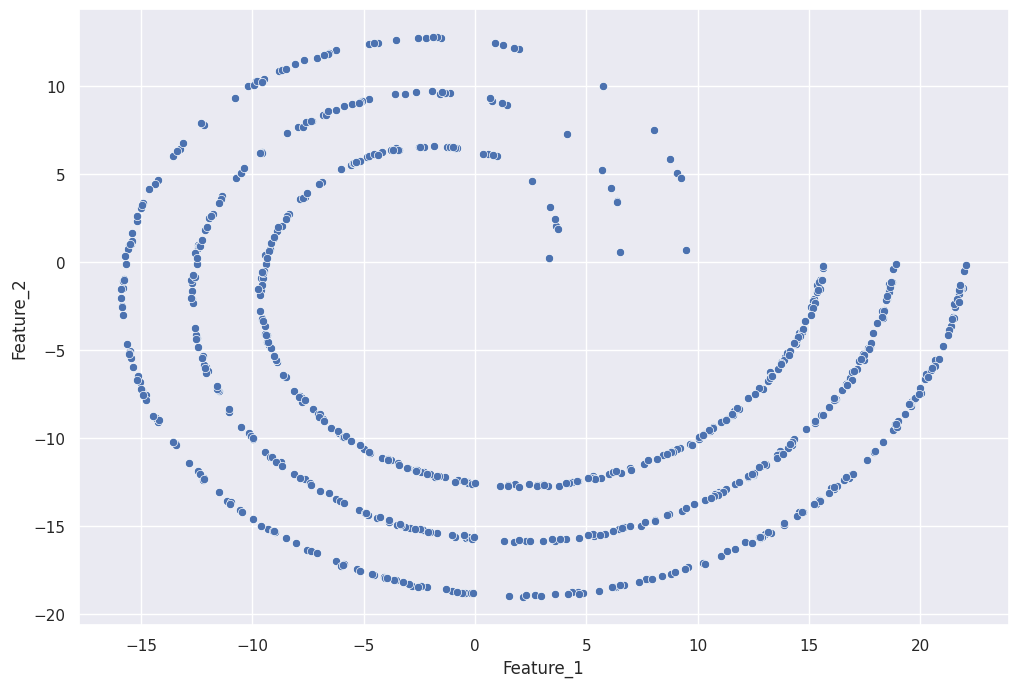

In [ ]:
sns.set(rc = {'figure.figsize': (12, 8)}) # Global Graph Size

sns.scatterplot(x = reduced_df1['Feature_1'], y = reduced_df1['Feature_2'])

In [ ]:
from sklearn.cluster import KMeans

# Apply K-Means clustering

kmeans = KMeans(n_clusters = 2, random_state = random_s)

reduced_df1['KMeans Cluster'] = kmeans.fit_predict(reduced_df1)
reduced_df1.head(3)

,Feature_1,Feature_2,KMeans Cluster
0,-9.619615,-0.910204,0
1,11.305911,-8.889836,1
2,0.567677,6.113420,0


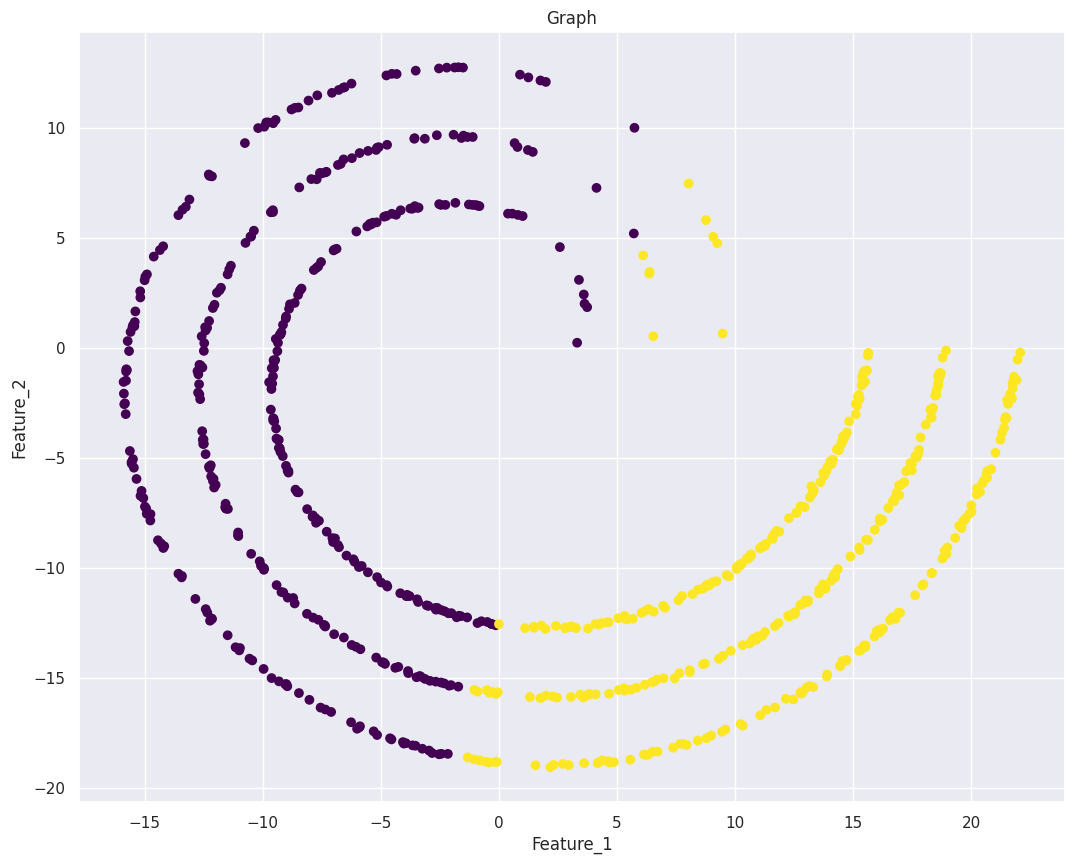

In [ ]:
# Plot K-Means results

plt.figure(figsize=(28, 10))

plt.subplot(1, 2, 1)
plt.scatter(reduced_df1['Feature_1'], reduced_df1['Feature_2'], c = reduced_df1['KMeans Cluster'], cmap = 'viridis')
plt.title('Graph')
plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.show()


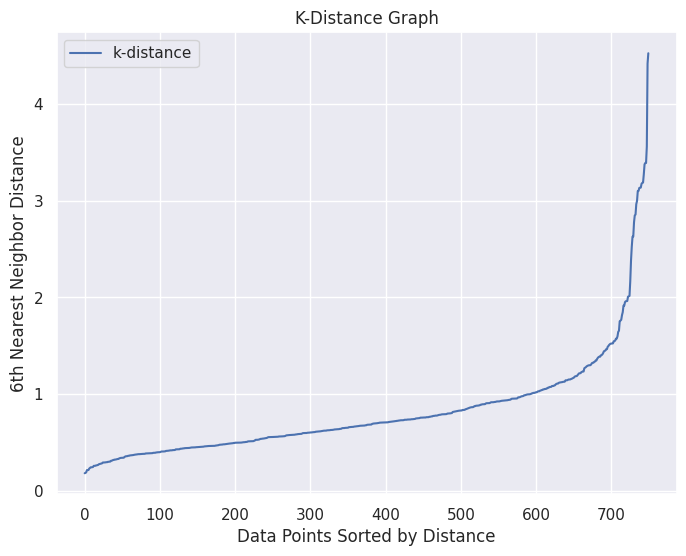

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Compute the K-Nearest Neighbors distances for k = min_samples
# min_samples = 4 (From 2 dimensions or two variables multiplied by 2) - Not absolute but can be a guide

min_samples = 6 # number of neighbors to consider for each point.
                # A point that will be classified as a core point, if it is at least X neighbors within a given radius (eps)

neighbors = NearestNeighbors(n_neighbors = min_samples) # Find the nearest neighbors of a data point
neighbors_fit = neighbors.fit(reduced_df1) # fits the NearestNeighbors to your dataset

distances, indices = neighbors_fit.kneighbors(reduced_df1) # distances, a matrix where each row contains the distances to the nearest X neighbors for each data point
                                                          # indices, a matrix where each row contains the indices of the nearest 8 neighbors for each data poin

                                                          # In DBSCAN, the eps value determines the maximum distance two points can be considered as neighbors

# Sort the distances (use the k-th nearest neighbor distance for each point)

k_distances = np.sort(distances[:,-1]) # extracts the largest (farthest) distance frome each point to its min_samples-th nearest neighbors
                                       # this is important because a DBSCAN uses this distance to determine whether a point is a core point or not
                                       # sorts the distances to the min_samples-th nearest neighbor in ascending order.

                                       # By sorting the distances, you can see where there’s a sudden jump in the distances,
                                       # which usually indicates a good threshold (eps) for DBSCAN.

# Plot the k-distance graph

plt.figure(figsize = (8,6), facecolor = 'white')
plt.plot(k_distances, label = 'k-distance')
plt.title('K-Distance Graph')
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

# Define range of potential eps values based on the k-distance plot

eps_values = np.linspace(0.2, 1.1, 10)

# Store S-Scores

s_scores = []

# Evaluate DBScan for each eps_values and calculate S-Score

for eps in eps_values:

  dbscan = DBSCAN(eps = eps, min_samples = min_samples)  # DBSCAN
  labels = dbscan.fit_predict(reduced_df1)

  # Check if the clustering has more than 1 cluster to calculate S-Score
  if len(set(labels)) > 1:

    score = silhouette_score(reduced_df1, labels)

  else:

    score = -1  # Invalid clustering scenario

  s_scores.append(score)

In [ ]:
# Look at s_scores
s_scores

[np.float64(-0.22462734519016378),
 np.float64(-0.4425674672012956),
 np.float64(-0.3956225981466099),
 np.float64(-0.09081802414430742),
 np.float64(0.09374332086790998),
 np.float64(0.1999101205768918),
 np.float64(0.20982540675967562),
 np.float64(0.23935280915193258),
 np.float64(0.13384359793079115),
 np.float64(0.046592061947687974)]

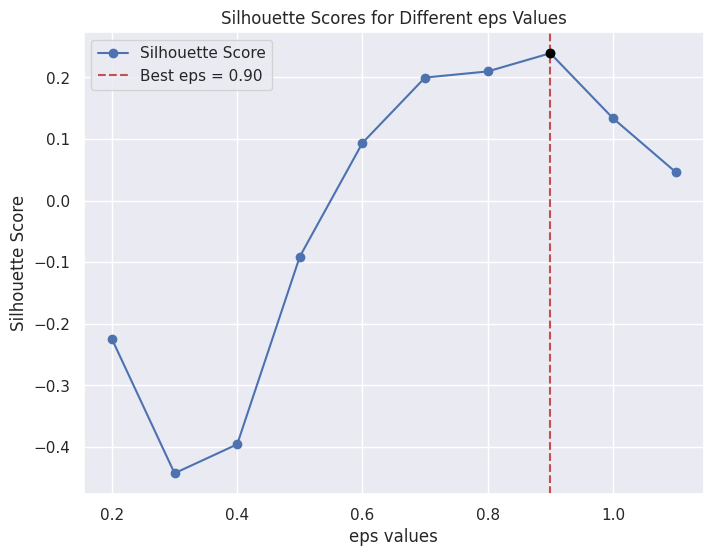

In [ ]:
# Plot the S-Scores

# Plot the Silhouette Scores for different eps values

plt.figure(figsize=(8, 6))

# Plot silhouette scores for each eps value

plt.plot(eps_values, s_scores, marker='o', label='Silhouette Score')

# Add labels and title
plt.title('Silhouette Scores for Different eps Values')
plt.xlabel('eps values')
plt.ylabel('Silhouette Score')
plt.grid(True)

# Highlight the best eps

best_eps_index = np.argmax(s_scores) # find the index of the best s_score
best_eps = eps_values[best_eps_index] # this will the best eps
best_s_score = s_scores[best_eps_index] # this will be the best s_score

plt.axvline(x = best_eps, color='r', linestyle='--', label = f'Best eps = {best_eps:.2f}')
plt.scatter(best_eps, best_s_score, color='black', zorder = 5)
plt.legend()
plt.show()

In [ ]:
reduced_df1

,Feature_1,Feature_2,KMeans Cluster
0,-9.619615,-0.910204,0
1,11.305911,-8.889836,1
2,0.567677,6.113420,0
3,-6.963633,4.481849,0
4,3.769435,-12.737114,1
...,...,...,...
745,20.375312,-6.522432,1
746,21.243000,-4.155653,1
747,-12.148540,-12.302063,0
748,-8.467792,-15.669910,0


In [ ]:
# Define DBSCAN model

final_model = DBSCAN(eps = 2.38, min_samples = 6)

# Fit the model to the scaled dataset

db_scan_clusters = final_model.fit_predict(reduced_df1.iloc[:,:2])

# Add the cluster labels to the scaled DataFrame

reduced_df1['DBSCAN Cluster'] = db_scan_clusters
reduced_df1.head(3)

,Feature_1,Feature_2,KMeans Cluster,DBSCAN Cluster
0,-9.619615,-0.910204,0,0
1,11.305911,-8.889836,1,0
2,0.567677,6.113420,0,0


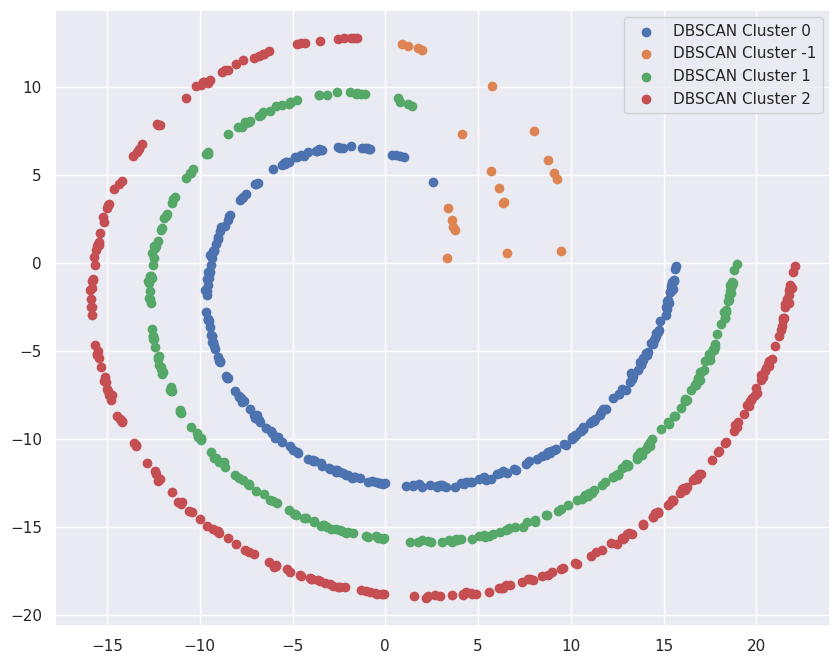

In [ ]:
# Plotting the clusters

plt.figure(figsize= (10,8))

# Scatter plot for the DBSCAN clusters

# Get the unique clusters

unique_clusters = reduced_df1['DBSCAN Cluster'].unique()

# Scatter plot for each cluster with labels

for cluster in unique_clusters:

    cluster_data = reduced_df1[reduced_df1['DBSCAN Cluster'] == cluster]

    plt.scatter(cluster_data['Feature_1'],
                cluster_data['Feature_2'],
                label=f'DBSCAN Cluster {cluster}', marker='o')


# Display the legend
plt.legend()

# Show the plot
plt.show()